# importing

In [12]:
%matplotlib widget
import csv
import logging
import math
import os
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import scipy
import scipy.optimize as spopt
from IPython.display import display
from lmfit import Minimizer, Model, Parameters, report_fit
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits import mplot3d
from numpy.fft import fft, fftfreq, ifft
from pylab import cm
from scipy import sparse, special, stats
from scipy.interpolate import interp1d, splev, splrep
from scipy.optimize import curve_fit
from matplotlib import colormaps

try:
    import qkit

    if qkit.module_available("matplotlib"):
        import matplotlib.pyplot as plt

        plot_enable = True
except (ImportError, AttributeError):
    try:
        import matplotlib.pyplot as plt

        plot_enable = True
    except ImportError:
        plot_enable = False

import matplotlib.patches as mpatches
#from statsmodels.nonparametric.smoothers_lowess import lowess

######################################################################

# some constants

k_b = 1.380649e-23
h = 6.62607015e-34
hbar = 1.0545718e-34


######################################################################
import importlib

#C:\Python310\Lib\site-packages\Geresdi_lab_code\AC\Analysis\resonator_tools

import Geresdi_lab_code
from Geresdi_lab_code.AC.Analysis import resonator_tools
import Geresdi_lab_code.AC.Analysis.resonator_tools.circuit as circuit

In [13]:
import resonator_master
from resonator_master.resonator import shunt
from resonator_master.resonator import see

In [14]:
from __future__ import division, absolute_import, print_function
%matplotlib inline

import lmfit

from resonator_master.resonator import background, shunt, see

In [15]:
from scipy.signal import find_peaks

In [16]:
### functions
def P_to_W(P_dBm):
    return 10 ** ((P_dBm - 30) / 10)


def W_to_P(P_W):
    return 10 * np.log10(P_W) + 30


def avg_photon(Pin, z0, zr, Ql, Qc, f_r):
    return (1 / np.pi) * (z0 / zr) * ((Ql**2) / Qc) * (Pin / (h * f_r**2))


def find_power(name_file, pattern_pow = "_p(.[0-9]*.[0-9]*?)dbm"):
    pattern_pow = "_p(.[0-9]*.[0-9]*?)dbm"
    return float(
        (re.search(pattern_pow, name_file.lower()).group(1))
        .replace("p", "")
        .replace("_", "")
        .replace("dbm", "")
    )


def find_temperature(name_file, pattern_T = "_t([0-9]*.[0-9]*?)mk"):
    pattern_T = "_t([0-9]*.[0-9]*?)mk"
    return float(
        (re.search(pattern_T, name_file.lower()).group(1))
        .replace("m", "")
        .replace("_", "")
        .replace("p", ".")
    )

def find_B(name_file, pattern_B = "Bz=([0-9]*.[0-9]*?)Tesla"):
    pattern_B =  "Bz=([0-9]*.[0-9]*?)Tesla"
    return float(
        (re.search(pattern_B, name_file.lower()))
        .replace("Bz=", "")
        .replace("Tesla", "")
    )


def remove_cable_delay(f_data,z_data, delay):
    return z_data/np.exp(2j*np.pi*f_data*delay)

In [17]:
import scipy.io
#mat = scipy.io.loadmat('file.mat')

# foldering


In [18]:
root_folder = r'C:\Users\shvetso1\OneDrive - Aalto University\Documents'

### fresh res

In [70]:
sub_folder = r'\xld_sample_data\Q1\2025-04-01 STS_Flux'

In [71]:
pth = root_folder + sub_folder

directory = os.fsencode(pth)

file_list = []
file_name_list = []
for file in os.listdir(directory):
     filename = os.fsdecode(file)
     if filename.endswith(".mat"): #Check how your files are named
            file_name_list.append(filename)
            continue
     else:
         continue

file_list = [os.path.join(pth,file).replace(os.sep, '/') for file in file_name_list]
print(np.size(file_list))

results_folder = r'\Results'
results_pth = pth+results_folder
Path(results_pth).mkdir(parents=True, exist_ok=True)

4


In [72]:
mat1 = scipy.io.loadmat(file_list[2])

In [82]:
plt.close('all')
freq = (mat1['freq_scan'][0])
x = pow(10, (mat1['mag_2darray'][2])/20)
phase = np.unwrap(mat1['pha_2darray'][2])+0*np.linspace(0,1500,1501)*7.7/1501
#phase = np.unwrap(mat1['pha_2darray'][2])
S21_vect = remove_cable_delay(freq, np.vectorize(complex)(x*np.cos(phase),(x*np.sin(phase))), delay = -100e-9)
#data=np.vectorize(complex)(mat1['mag_2darray'][2]*np.cos(phase),(mat1['mag_2darray'][2]*np.sin(phase)))
data = S21_vect

In [89]:
# Background model and parameters
background_model = background.MagnitudePhaseDelay()
magnitude = 0.01
phase = 0
delay = 0  # This corresponds to a long microwave cable
lsf = shunt.LinearShuntFitter(frequency=freq, data=data, background_model=background.MagnitudePhaseDelay())

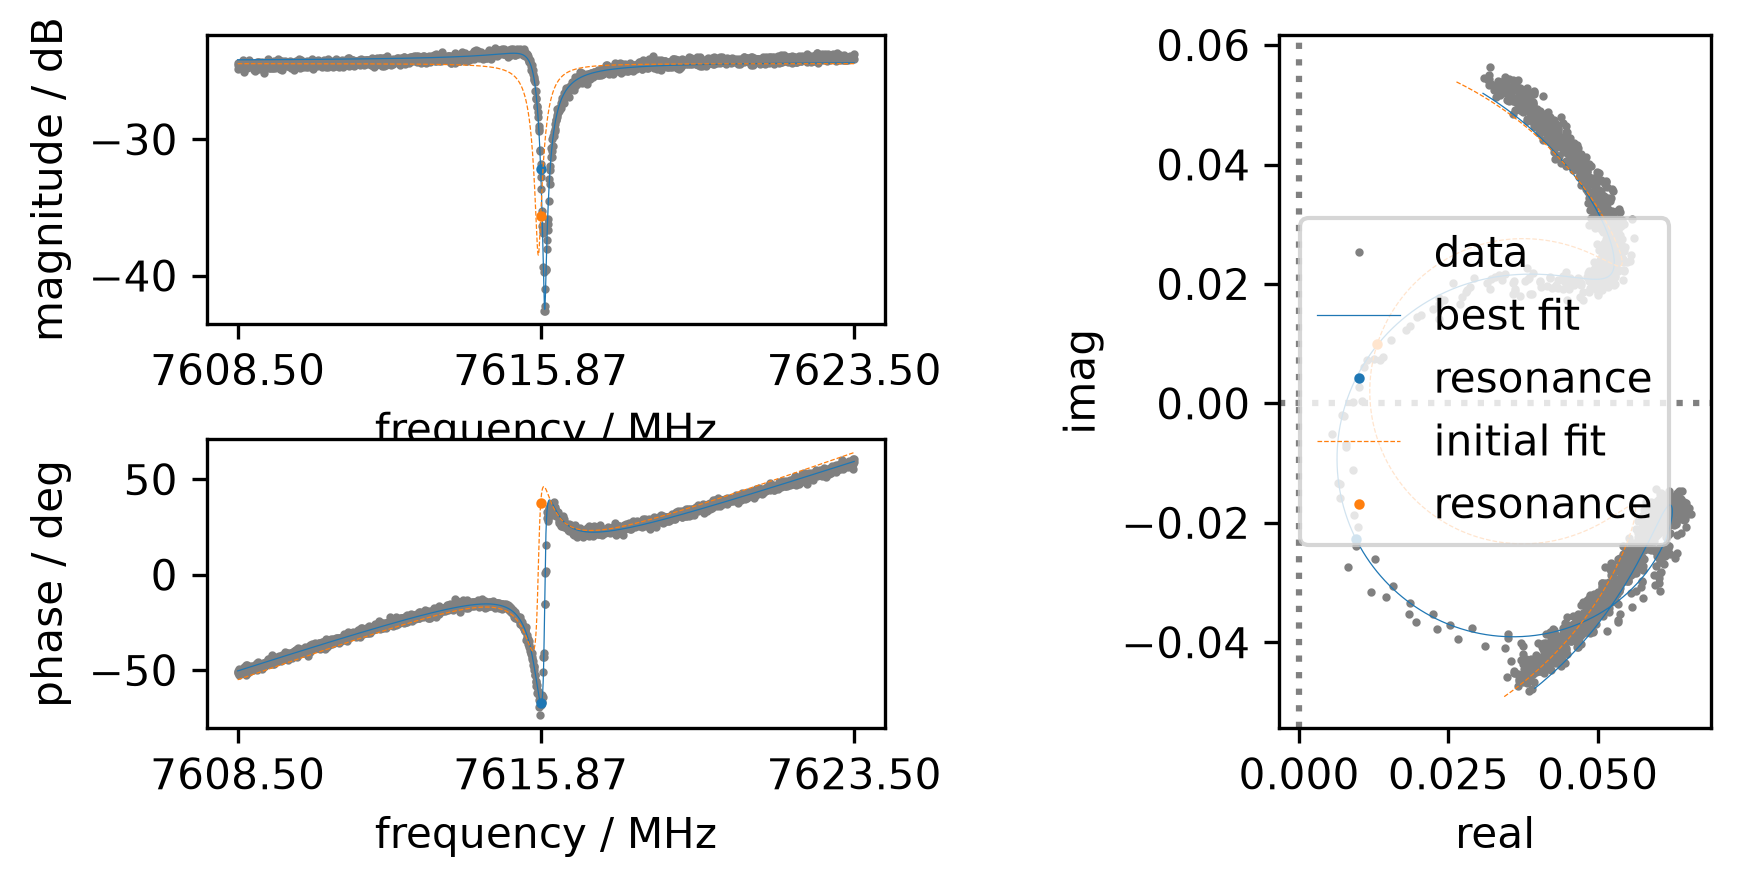

In [90]:
fig, (ax_magnitude, ax_phase, ax_complex) = see.triptych(resonator=lsf, plot_initial=True, frequency_scale=1e-6, normalize=False, figure_settings={'figsize': (7, 3), 'dpi': 300})
ax_complex.legend()
fig.savefig("example_raw.png")

In [33]:
print(lsf.result.fit_report())

[[Model]]
    (Model(magnitude_phase_delay) * Model(linear_shunt))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 57
    # data points      = 3002
    # variables        = 7
    chi-square         = 0.00859980
    reduced chi-square = 2.8714e-06
    Akaike info crit   = -38300.6787
    Bayesian info crit = -38258.6295
    R-squared          = np.complex128(-3240835902257.349-1369878005309.885j)
[[Variables]]
    frequency_reference:  7.616e+09 (fixed)
    magnitude:            0.06116646 +/- 4.6252e-05 (0.08%) (init = 0.05986493)
    phase:                0.15585798 +/- 7.5462e-04 (0.48%) (init = 0.1584902)
    delay:                1.3422e-09 +/- 2.8020e-11 (2.09%) (init = 2.985743e-09)
    resonance_frequency:  7.6159e+09 +/- 1734.28076 (0.00%) (init = 7.615815e+09)
    coupling_loss:        5.7871e-05 +/- 3.2458e-07 (0.56%) (init = 6.110586e-05)
    internal_loss:        8.7622e-06 +/- 3.3626e-07 (3.84%) (init = 1.505145e-05)
    asymmetry:            0

In [34]:
print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))
print("The coupling quality factor is Q_c = {:.0f}".format(lsf.Q_c))
print("The total quality factor is Q_t = {:.0f}".format(lsf.Q_t))
print("The standard error of the resonance frequency is: {:.0f} Hz".format(lsf.f_r_error))
print("The total energy decay rate is 2 pi f_r / Q_t = {:.0f} s^-1".format(lsf.total_energy_decay_rate))
#print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))


The internal quality factor is Q_i = 114126
The coupling quality factor is Q_c = 17280
The total quality factor is Q_t = 15007
The standard error of the resonance frequency is: 1734 Hz
The total energy decay rate is 2 pi f_r / Q_t = 3188542 s^-1


In [35]:
lsf.resonance_frequency/1e9

7.615872502746925

### 6 months later

In [91]:
sub_folder = r'\xld_sample_data\Q1\2025-10-30 STS_Flux'

In [92]:
pth = root_folder + sub_folder

directory = os.fsencode(pth)

file_list = []
file_name_list = []
for file in os.listdir(directory):
     filename = os.fsdecode(file)
     if filename.endswith(".mat"): #Check how your files are named
            file_name_list.append(filename)
            continue
     else:
         continue

file_list = [os.path.join(pth,file).replace(os.sep, '/') for file in file_name_list]
print(np.size(file_list))

results_folder = r'\Results'
results_pth = pth+results_folder
Path(results_pth).mkdir(parents=True, exist_ok=True)

2


In [93]:
print(file_list[1])

C:/Users/shvetso1/OneDrive - Aalto University/Documents/xld_sample_data/Q1/2025-10-30 STS_Flux/S12(7.614to7.617GHzx301)(0.2to0.4mAx41)_P=-45dBm-20251030T153557.mat


In [94]:
mat2 = scipy.io.loadmat(file_list[1])

In [95]:
mat2

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Thu Oct 30 15:39:39 2025',
 '__version__': '1.0',
 '__globals__': [],
 'Att_input': array([[62]], dtype=uint8),
 'Att_probe': array([[3]], dtype=uint8),
 'Conf': array([[(array(['STS_OUT_1p2_with_TWPA_IN1.13'], dtype='<U28'), array([[100]], dtype=uint8))]],
       dtype=[('setup', 'O'), ('IFbw', 'O')]),
 'flux': array([[0.2  , 0.205, 0.21 , 0.215, 0.22 , 0.225, 0.23 , 0.235, 0.24 ,
         0.245, 0.25 , 0.255, 0.26 , 0.265, 0.27 , 0.275, 0.28 , 0.285,
         0.29 , 0.295, 0.3  , 0.305, 0.31 , 0.315, 0.32 , 0.325, 0.33 ,
         0.335, 0.34 , 0.345, 0.35 , 0.355, 0.36 , 0.365, 0.37 , 0.375,
         0.38 , 0.385, 0.39 , 0.395, 0.4  ]]),
 'freq_scan': array([[7.61375e+09, 7.61376e+09, 7.61377e+09, 7.61378e+09, 7.61379e+09,
         7.61380e+09, 7.61381e+09, 7.61382e+09, 7.61383e+09, 7.61384e+09,
         7.61385e+09, 7.61386e+09, 7.61387e+09, 7.61388e+09, 7.61389e+09,
         7.61390e+09, 7.61391e+09, 7.61392e+09, 

In [96]:
mat2['flux'][0][20]

np.float64(0.30000000000000004)

In [97]:
plt.close('all')
freq = (mat2['freq_scan'][0])
x = pow(10, (mat2['mag_2darray'][2])/20)
phase = np.unwrap(mat2['pha_2darray'][20])+0*np.linspace(0,300,301)*7.7/301
#phase = np.unwrap(mat1['pha_2darray'][2])
S21_vect = remove_cable_delay(freq, np.vectorize(complex)(x*np.cos(phase),(x*np.sin(phase))), delay = 0)
#data=np.vectorize(complex)(mat1['mag_2darray'][2]*np.cos(phase),(mat1['mag_2darray'][2]*np.sin(phase)))
data = S21_vect

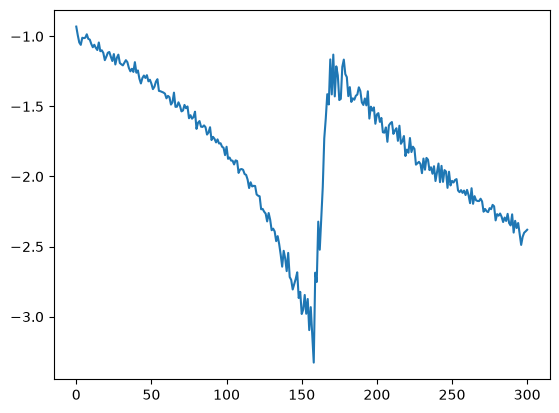

In [99]:
plt.close('all')
plt.plot(np.unwrap(mat2['pha_2darray'][20])+0*np.linspace(0,300,301)*4/301)

In [100]:
# Background model and parameters
background_model = background.MagnitudePhaseDelay()
magnitude = 0.01
phase = 0
delay = 300e-9  # This corresponds to a long microwave cable
lsf = shunt.LinearShuntFitter(frequency=freq, data=data, background_model=background.MagnitudePhaseDelay())

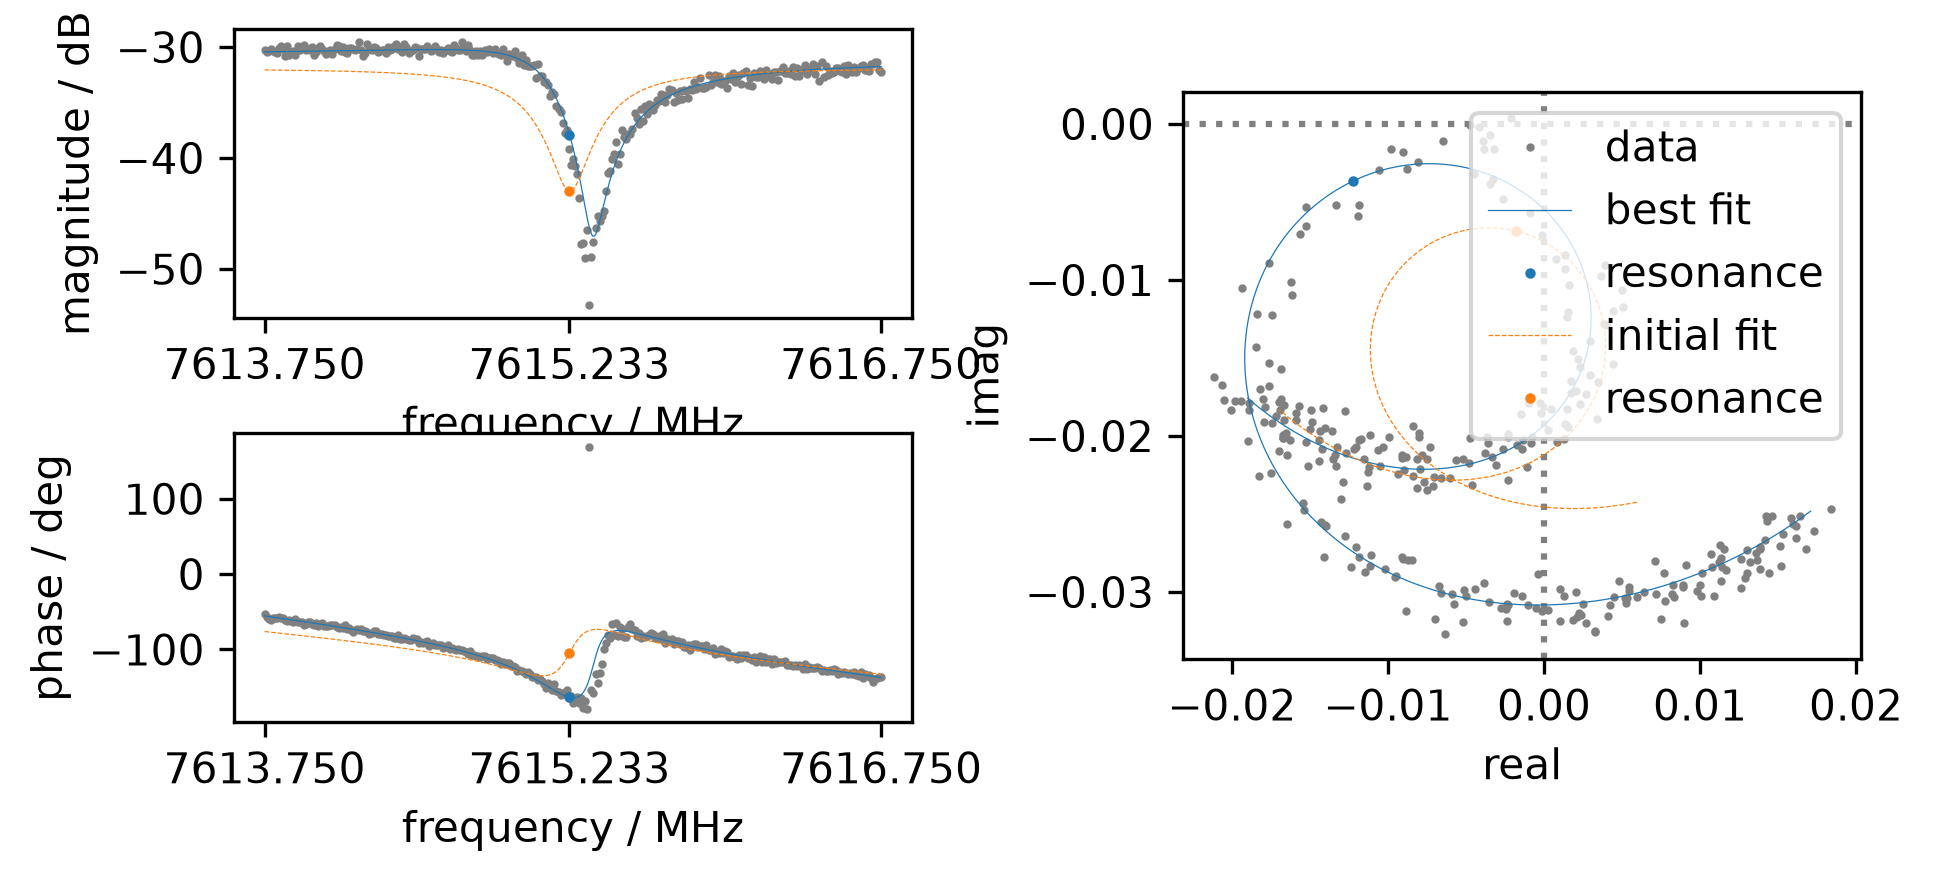

In [101]:
fig, (ax_magnitude, ax_phase, ax_complex) = see.triptych(resonator=lsf, plot_initial=True, frequency_scale=1e-6, normalize=False, figure_settings={'figsize': (7, 3), 'dpi': 300})
ax_complex.legend()
fig.savefig("example_raw.png")

In [344]:
print(lsf.result.fit_report())

[[Model]]
    (Model(magnitude_phase_delay) * Model(linear_shunt))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 49
    # data points      = 602
    # variables        = 7
    chi-square         = 7.1537e-04
    reduced chi-square = 1.2023e-06
    Akaike info crit   = -8199.06641
    Bayesian info crit = -8168.26461
    R-squared          = (0.9805105298478158-0.028367275834598846j)
[[Variables]]
    frequency_reference:  7.61525e+09 (fixed)
    magnitude:            0.02843609 +/- 9.1705e-05 (0.32%) (init = 0.02537949)
    phase:               -1.67741686 +/- 0.00302883 (0.18%) (init = -1.822872)
    delay:               -9.1712e-08 +/- 5.7843e-10 (0.63%) (init = -6.672952e-08)
    resonance_frequency:  7.6152e+09 +/- 3195.40911 (0.00%) (init = 7.615235e+09)
    coupling_loss:        6.0274e-05 +/- 7.4069e-07 (1.23%) (init = 5.392511e-05)
    internal_loss:        1.2265e-05 +/- 5.3594e-07 (4.37%) (init = 2.092485e-05)
    asymmetry:            0.4995869

In [347]:
print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))
print("The coupling quality factor is Q_c = {:.0f}".format(lsf.Q_c))
print("The total quality factor is Q_t = {:.0f}".format(lsf.Q_t))
print("The standard error of the resonance frequency is: {:.0f} Hz".format(lsf.f_r_error))
print("The total energy decay rate is 2 pi f_r / Q_t = {:.0f} s^-1".format(lsf.total_energy_decay_rate))
#print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))


The internal quality factor is Q_i = 81532
The coupling quality factor is Q_c = 16591
The total quality factor is Q_t = 13786
The standard error of the resonance frequency is: 3195 Hz
The total energy decay rate is 2 pi f_r / Q_t = 3470852 s^-1


In [346]:
lsf.resonance_frequency/1e9

7.615233301717991

### Elias sample (manhattan type)

In [102]:
sub_folder = r'\xld_sample_data\ES-004-A\Q1\2025-09-01 STS_Power'

In [103]:
pth = root_folder + sub_folder

directory = os.fsencode(pth)

file_list = []
file_name_list = []
for file in os.listdir(directory):
     filename = os.fsdecode(file)
     if filename.endswith(".mat"): #Check how your files are named
            file_name_list.append(filename)
            continue
     else:
         continue

file_list = [os.path.join(pth,file).replace(os.sep, '/') for file in file_name_list]
print(np.size(file_list))

results_folder = r'\Results'
results_pth = pth+results_folder
Path(results_pth).mkdir(parents=True, exist_ok=True)

6


In [104]:
print(file_list[2])

C:/Users/shvetso1/OneDrive - Aalto University/Documents/xld_sample_data/ES-004-A/Q1/2025-09-01 STS_Power/S12(f=5.94to5.95GHz)(P=10to-40dBm)_flux=0mA-20250901T124135.mat


In [105]:
mat3 = scipy.io.loadmat(file_list[2])

In [106]:
mat3

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Sep  1 12:42:16 2025',
 '__version__': '1.0',
 '__globals__': [],
 'Att_input': array([[62]], dtype=uint8),
 'Att_probe': array([[23]], dtype=uint8),
 'Conf': array([[(array(['STS_OUT_1p8_IN_2p8_'], dtype='<U19'), array([[100]], dtype=uint8))]],
       dtype=[('setup', 'O'), ('IFbw', 'O')]),
 'flux': array([[0]], dtype=uint8),
 'freq_scan': array([[5.94450e+09, 5.94451e+09, 5.94452e+09, 5.94453e+09, 5.94454e+09,
         5.94455e+09, 5.94456e+09, 5.94457e+09, 5.94458e+09, 5.94459e+09,
         5.94460e+09, 5.94461e+09, 5.94462e+09, 5.94463e+09, 5.94464e+09,
         5.94465e+09, 5.94466e+09, 5.94467e+09, 5.94468e+09, 5.94469e+09,
         5.94470e+09, 5.94471e+09, 5.94472e+09, 5.94473e+09, 5.94474e+09,
         5.94475e+09, 5.94476e+09, 5.94477e+09, 5.94478e+09, 5.94479e+09,
         5.94480e+09, 5.94481e+09, 5.94482e+09, 5.94483e+09, 5.94484e+09,
         5.94485e+09, 5.94486e+09, 5.94487e+09, 5.94488e+09, 5.9448

In [107]:
mat3['power'][0][5]

np.int16(-40)

In [125]:
plt.close('all')
freq = (mat3['freq_scan'][0])
x = pow(10, (mat3['mag_2darray'][5])/20)
phase = np.unwrap(mat3['pha_2darray'][5])
#phase = np.unwrap(mat1['pha_2darray'][2])
S21_vect = remove_cable_delay(freq, np.vectorize(complex)(x*np.cos(phase),(x*np.sin(phase))), delay = -110e-9)
#data=np.vectorize(complex)(mat1['mag_2darray'][2]*np.cos(phase),(mat1['mag_2darray'][2]*np.sin(phase)))
data = S21_vect

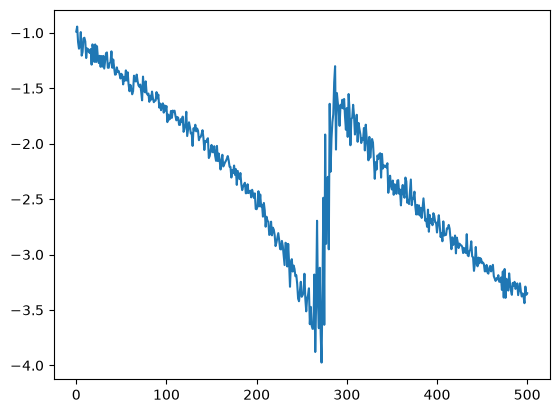

In [126]:
plt.close('all')
plt.plot(np.unwrap(mat3['pha_2darray'][5])+0*np.linspace(0,500,501)*4/501)

In [127]:
# Background model and parameters
background_model = background.MagnitudePhaseDelay()
magnitude = 0.01
phase = 0
delay = 0  # This corresponds to a long microwave cable
lsf = shunt.LinearShuntFitter(frequency=freq, data=data, background_model=background.MagnitudePhaseDelay())

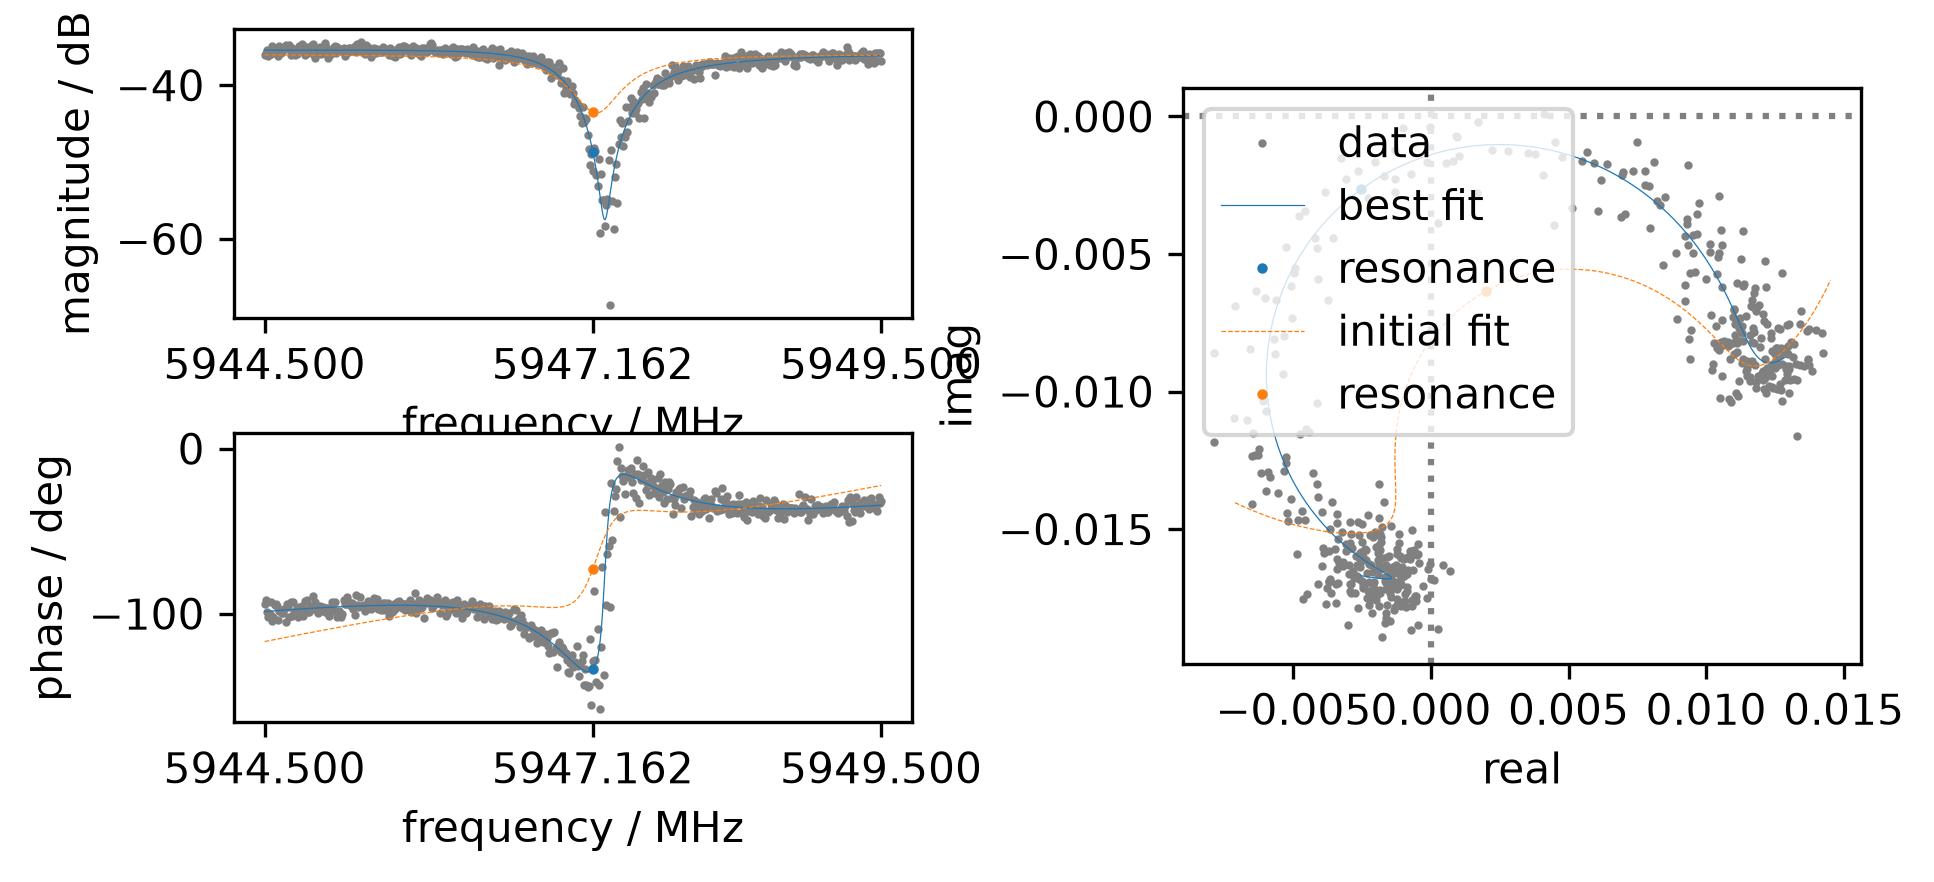

In [128]:
fig, (ax_magnitude, ax_phase, ax_complex) = see.triptych(resonator=lsf, plot_initial=True, frequency_scale=1e-6, normalize=False, figure_settings={'figsize': (7, 3), 'dpi': 300})
ax_complex.legend()
fig.savefig("example_raw.png")

In [112]:
print(lsf.result.fit_report())

[[Model]]
    (Model(magnitude_phase_delay) * Model(linear_shunt))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 49
    # data points      = 1002
    # variables        = 7
    chi-square         = 7.9589e-04
    reduced chi-square = 7.9989e-07
    Akaike info crit   = -14059.8904
    Bayesian info crit = -14025.5222
    R-squared          = np.complex128(0.9997533196064787-0.00011436183387858158j)
[[Variables]]
    frequency_reference:  5.947e+09 (fixed)
    magnitude:            0.01654367 +/- 5.7664e-05 (0.35%) (init = 0.01590725)
    phase:               -2.23833047 +/- 0.00329357 (0.15%) (init = -2.298998)
    delay:               -8.4907e-08 +/- 3.7900e-10 (0.45%) (init = -6.289708e-08)
    resonance_frequency:  5.9472e+09 +/- 5664.88368 (0.00%) (init = 5.947145e+09)
    coupling_loss:        1.4306e-04 +/- 1.6949e-06 (1.18%) (init = 8.489273e-05)
    internal_loss:        1.2854e-05 +/- 1.1521e-06 (8.96%) (init = 5.298856e-05)
    asymmetry:       

In [113]:
print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))
print("The coupling quality factor is Q_c = {:.0f}".format(lsf.Q_c))
print("The total quality factor is Q_t = {:.0f}".format(lsf.Q_t))
print("The standard error of the resonance frequency is: {:.0f} Hz".format(lsf.f_r_error))
print("The total energy decay rate is 2 pi f_r / Q_t = {:.0f} s^-1".format(lsf.total_energy_decay_rate))
#print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))


The internal quality factor is Q_i = 77795
The coupling quality factor is Q_c = 6990
The total quality factor is Q_t = 6414
The standard error of the resonance frequency is: 5665 Hz
The total energy decay rate is 2 pi f_r / Q_t = 5825920 s^-1


In [114]:
lsf.resonance_frequency/1e9

5.947162328220566

# ES 004 D (Elias)

### Q1

In [8]:
sub_folder = r'\xld_sample_data\ES-004-D\Q1\2025-11-10 STS_Power'

In [12]:
pth = root_folder + sub_folder

directory = os.fsencode(pth)

file_list = []
file_name_list = []
for file in os.listdir(directory):
     filename = os.fsdecode(file)
     if filename.endswith(".mat"): #Check how your files are named
            file_name_list.append(filename)
            continue
     else:
         continue

file_list = [os.path.join(pth,file).replace(os.sep, '/') for file in file_name_list]
print(np.size(file_list))

results_folder = r'\Results'
results_pth = pth+results_folder
Path(results_pth).mkdir(parents=True, exist_ok=True)
print(results_pth)

5
C:\Users\shvetso1\OneDrive - Aalto University\Documents\xld_sample_data\ES-004-D\Q1\2025-11-10 STS_Power\Results


In [14]:
print(file_list[4])

C:/Users/shvetso1/OneDrive - Aalto University/Documents/xld_sample_data/ES-004-D/Q1/2025-11-10 STS_Power/S12(f=5.49to5.49GHz)(P=10to-55dBm)_flux=0mA-20251110T110729.mat


In [16]:
mat = scipy.io.loadmat(file_list[4])

In [17]:
mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Nov 10 11:08:35 2025',
 '__version__': '1.0',
 '__globals__': [],
 'Att_input': array([[62]], dtype=uint8),
 'Att_probe': array([[13]], dtype=uint8),
 'Conf': array([[(array(['STS_OUT_1p2_IN_1p11_'], dtype='<U20'), array([[75]], dtype=uint8))]],
       dtype=[('setup', 'O'), ('IFbw', 'O')]),
 'flux': array([[0]], dtype=uint8),
 'freq_scan': array([[5.487900e+09, 5.487905e+09, 5.487910e+09, 5.487915e+09,
         5.487920e+09, 5.487925e+09, 5.487930e+09, 5.487935e+09,
         5.487940e+09, 5.487945e+09, 5.487950e+09, 5.487955e+09,
         5.487960e+09, 5.487965e+09, 5.487970e+09, 5.487975e+09,
         5.487980e+09, 5.487985e+09, 5.487990e+09, 5.487995e+09,
         5.488000e+09, 5.488005e+09, 5.488010e+09, 5.488015e+09,
         5.488020e+09, 5.488025e+09, 5.488030e+09, 5.488035e+09,
         5.488040e+09, 5.488045e+09, 5.488050e+09, 5.488055e+09,
         5.488060e+09, 5.488065e+09, 5.488070e+09, 5.488075e+09,


In [19]:
mat['power'][0][10]

-40

In [21]:
plt.close('all')
freq = (mat['freq_scan'][0])
x = pow(10, (mat['mag_2darray'][10])/20)
phase = np.unwrap(mat['pha_2darray'][10])
#phase = np.unwrap(mat1['pha_2darray'][2])
S21_vect = remove_cable_delay(freq, np.vectorize(complex)(x*np.cos(phase),(x*np.sin(phase))), delay = 0)
#data=np.vectorize(complex)(mat1['mag_2darray'][2]*np.cos(phase),(mat1['mag_2darray'][2]*np.sin(phase)))
data = S21_vect

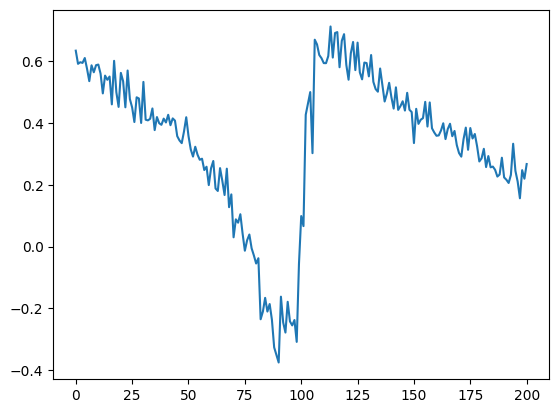

In [24]:
plt.close('all')
plt.plot(np.unwrap(mat['pha_2darray'][10])+0*np.linspace(0,200,201)*4/201)

In [25]:
# Background model and parameters
background_model = background.MagnitudePhaseDelay()
magnitude = 0.01
phase = 0
delay = 300e-9  # This corresponds to a long microwave cable
lsf = shunt.LinearShuntFitter(frequency=freq, data=data, background_model=background.MagnitudePhaseDelay())

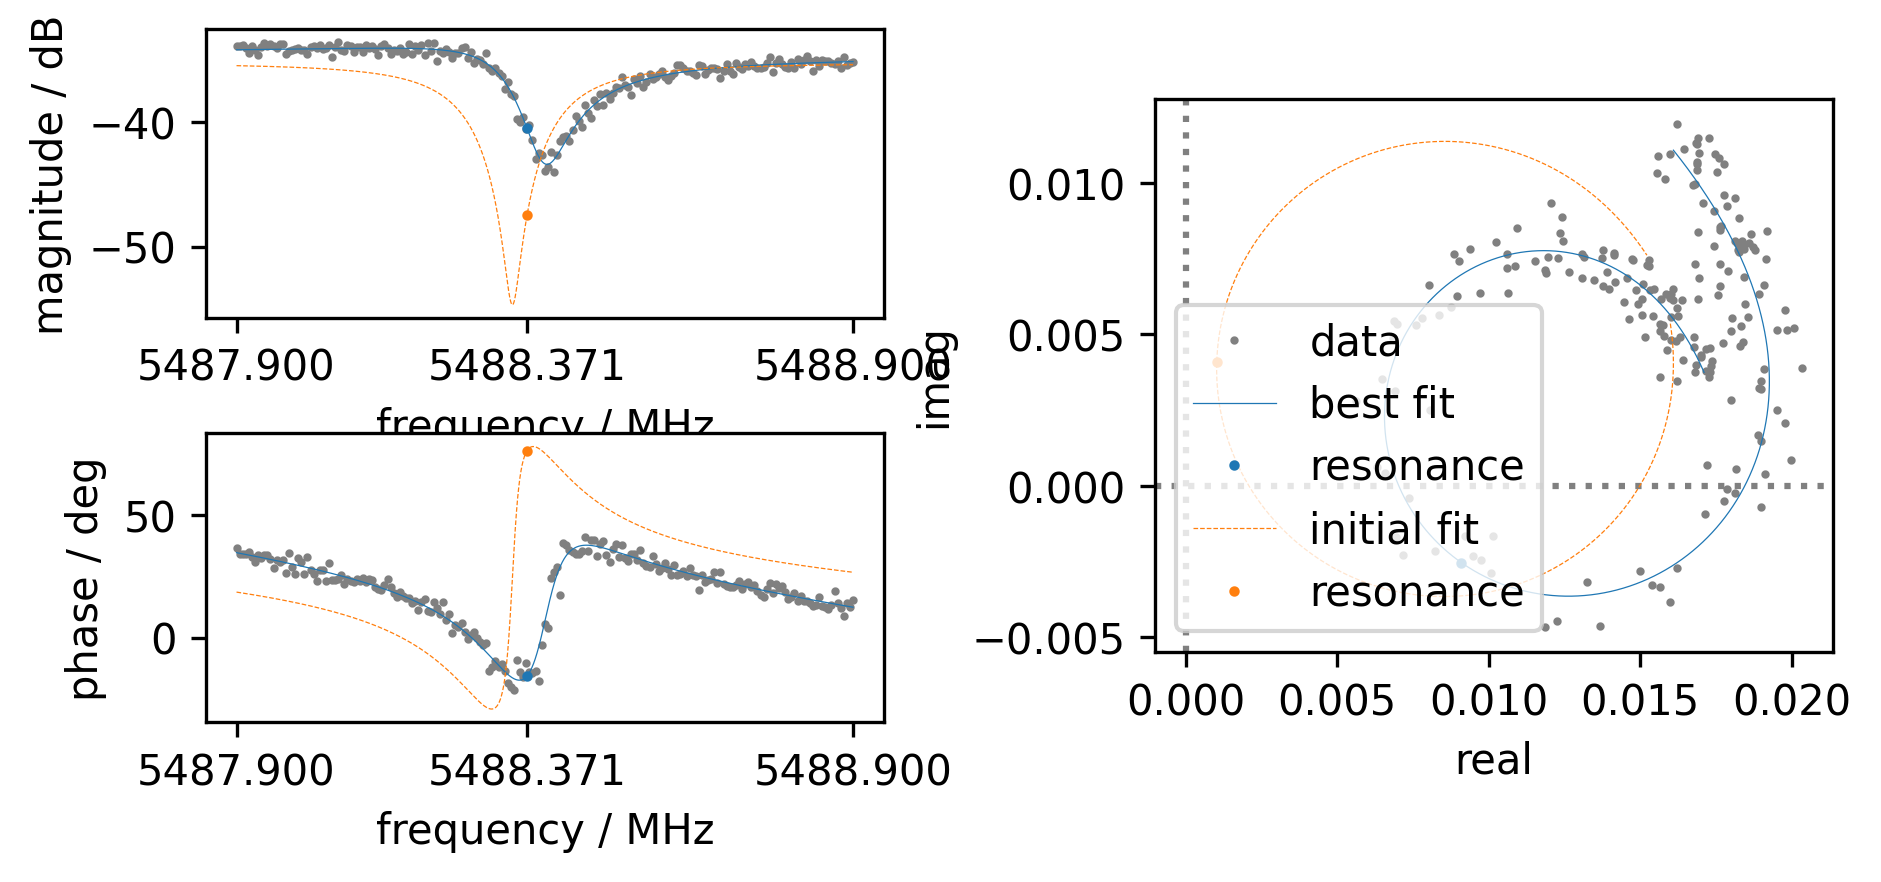

In [26]:
fig, (ax_magnitude, ax_phase, ax_complex) = see.triptych(resonator=lsf, plot_initial=True, frequency_scale=1e-6, normalize=False, figure_settings={'figsize': (7, 3), 'dpi': 300})
ax_complex.legend()
fig.savefig("example_raw.png")

In [27]:
print(lsf.result.fit_report())

[[Model]]
    (Model(magnitude_phase_delay) * Model(linear_shunt))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 65
    # data points      = 402
    # variables        = 7
    chi-square         = 1.8326e-04
    reduced chi-square = 4.6395e-07
    Akaike info crit   = -5855.62385
    Bayesian info crit = -5827.64868
    R-squared          = -1.8326e+11
[[Variables]]
    frequency_reference:  5.4884e+09 (fixed)
    magnitude:            0.01869826 +/- 6.9194e-05 (0.37%) (init = 0.01731726)
    phase:                0.41877855 +/- 0.00340710 (0.81%) (init = 0.4123633)
    delay:               -9.5009e-08 +/- 1.9559e-09 (2.06%) (init = -3.695579e-08)
    resonance_frequency:  5.4884e+09 +/- 1540.75283 (0.00%) (init = 5.488348e+09)
    coupling_loss:        1.9276e-05 +/- 3.8579e-07 (2.00%) (init = 3.418611e-05)
    internal_loss:        1.2000e-05 +/- 3.9043e-07 (3.25%) (init = 4.076772e-06)
    asymmetry:            0.53310899 +/- 0.01838354 (3.45%) (init =

In [29]:
print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))
print("The coupling quality factor is Q_c = {:.0f}".format(lsf.Q_c))
print("The total quality factor is Q_t = {:.0f}".format(lsf.Q_t))
print("The standard error of the resonance frequency is: {:.0f} Hz".format(lsf.f_r_error))
print("The total energy decay rate is 2 pi f_r / Q_t = {:.0f} s^-1".format(lsf.total_energy_decay_rate))
#print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))


The internal quality factor is Q_i = 83333
The coupling quality factor is Q_c = 51879
The total quality factor is Q_t = 31974
The standard error of the resonance frequency is: 1541 Hz
The total energy decay rate is 2 pi f_r / Q_t = 1078521 s^-1


In [30]:
lsf.resonance_frequency/1e9

5.488371216405059

### Q2

In [31]:
sub_folder = r'\xld_sample_data\ES-004-D\Q2\2025-11-10 STS_Power'

In [32]:
pth = root_folder + sub_folder

directory = os.fsencode(pth)

file_list = []
file_name_list = []
for file in os.listdir(directory):
     filename = os.fsdecode(file)
     if filename.endswith(".mat"): #Check how your files are named
            file_name_list.append(filename)
            continue
     else:
         continue

file_list = [os.path.join(pth,file).replace(os.sep, '/') for file in file_name_list]
print(np.size(file_list))

results_folder = r'\Results'
results_pth = pth+results_folder
Path(results_pth).mkdir(parents=True, exist_ok=True)
print(results_pth)

1
C:\Users\shvetso1\OneDrive - Aalto University\Documents\xld_sample_data\ES-004-D\Q2\2025-11-10 STS_Power\Results


In [33]:
print(file_list[0])

C:/Users/shvetso1/OneDrive - Aalto University/Documents/xld_sample_data/ES-004-D/Q2/2025-11-10 STS_Power/S12(f=5.72to5.72GHz)(P=10to-45dBm)_flux=0mA-20251110T111631.mat


In [34]:
mat = scipy.io.loadmat(file_list[0])

In [35]:
mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Nov 10 11:17:27 2025',
 '__version__': '1.0',
 '__globals__': [],
 'Att_input': array([[62]], dtype=uint8),
 'Att_probe': array([[13]], dtype=uint8),
 'Conf': array([[(array(['STS_OUT_1p2_IN_1p11_'], dtype='<U20'), array([[75]], dtype=uint8))]],
       dtype=[('setup', 'O'), ('IFbw', 'O')]),
 'flux': array([[0]], dtype=uint8),
 'freq_scan': array([[5.718500e+09, 5.718505e+09, 5.718510e+09, 5.718515e+09,
         5.718520e+09, 5.718525e+09, 5.718530e+09, 5.718535e+09,
         5.718540e+09, 5.718545e+09, 5.718550e+09, 5.718555e+09,
         5.718560e+09, 5.718565e+09, 5.718570e+09, 5.718575e+09,
         5.718580e+09, 5.718585e+09, 5.718590e+09, 5.718595e+09,
         5.718600e+09, 5.718605e+09, 5.718610e+09, 5.718615e+09,
         5.718620e+09, 5.718625e+09, 5.718630e+09, 5.718635e+09,
         5.718640e+09, 5.718645e+09, 5.718650e+09, 5.718655e+09,
         5.718660e+09, 5.718665e+09, 5.718670e+09, 5.718675e+09,


In [37]:
mat['power'][0][10]

-40

In [42]:
np.size(mat['pha_2darray'][10])

201

In [43]:
plt.close('all')
freq = (mat['freq_scan'][0])
x = pow(10, (mat['mag_2darray'][10])/20)
phase = np.unwrap(mat['pha_2darray'][10])
#phase = np.unwrap(mat1['pha_2darray'][2])
S21_vect = remove_cable_delay(freq, np.vectorize(complex)(x*np.cos(phase),(x*np.sin(phase))), delay = 0)
#data=np.vectorize(complex)(mat1['mag_2darray'][2]*np.cos(phase),(mat1['mag_2darray'][2]*np.sin(phase)))
data = S21_vect

In [44]:
# Background model and parameters
background_model = background.MagnitudePhaseDelay()
magnitude = 0.01
phase = 0
delay = 300e-9  # This corresponds to a long microwave cable
lsf = shunt.LinearShuntFitter(frequency=freq, data=data, background_model=background.MagnitudePhaseDelay())

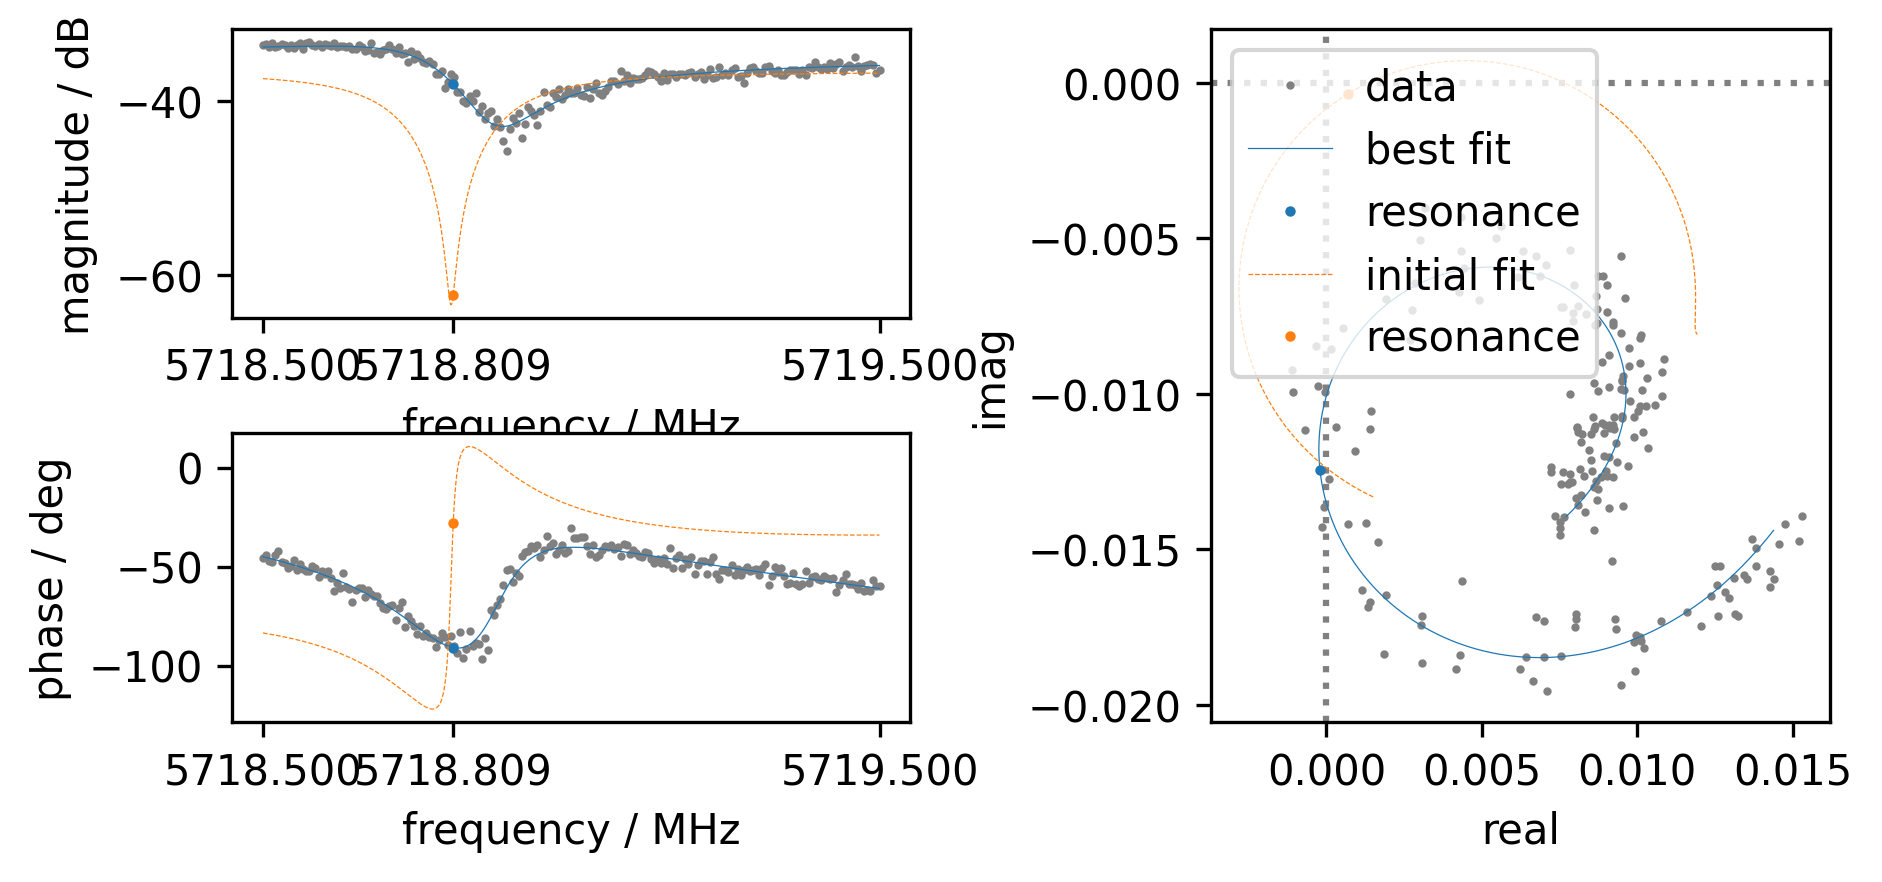

In [45]:
fig, (ax_magnitude, ax_phase, ax_complex) = see.triptych(resonator=lsf, plot_initial=True, frequency_scale=1e-6, normalize=False, figure_settings={'figsize': (7, 3), 'dpi': 300})
ax_complex.legend()
fig.savefig("example_raw.png")

In [46]:
print(lsf.result.fit_report())

[[Model]]
    (Model(magnitude_phase_delay) * Model(linear_shunt))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 77
    # data points      = 402
    # variables        = 7
    chi-square         = 2.5659e-04
    reduced chi-square = 6.4959e-07
    Akaike info crit   = -5720.32638
    Bayesian info crit = -5692.35122
    R-squared          = -2.5659e+11
[[Variables]]
    frequency_reference:  5.719e+09 (fixed)
    magnitude:            0.01787532 +/- 1.0857e-04 (0.61%) (init = 0.01469713)
    phase:               -0.85154994 +/- 0.00502805 (0.59%) (init = -0.9185583)
    delay:               -9.6800e-08 +/- 2.9377e-09 (3.03%) (init = 4.359311e-08)
    resonance_frequency:  5.7188e+09 +/- 2439.73637 (0.00%) (init = 5.718805e+09)
    coupling_loss:        2.4242e-05 +/- 7.6064e-07 (3.14%) (init = 4.588007e-05)
    internal_loss:        2.0522e-05 +/- 6.3322e-07 (3.09%) (init = 2.206896e-06)
    asymmetry:            0.96827902 +/- 0.03200474 (3.31%) (init = 

In [47]:
print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))
print("The coupling quality factor is Q_c = {:.0f}".format(lsf.Q_c))
print("The total quality factor is Q_t = {:.0f}".format(lsf.Q_t))
print("The standard error of the resonance frequency is: {:.0f} Hz".format(lsf.f_r_error))
print("The total energy decay rate is 2 pi f_r / Q_t = {:.0f} s^-1".format(lsf.total_energy_decay_rate))
#print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))


The internal quality factor is Q_i = 48727
The coupling quality factor is Q_c = 41251
The total quality factor is Q_t = 22339
The standard error of the resonance frequency is: 2440 Hz
The total energy decay rate is 2 pi f_r / Q_t = 1608479 s^-1


In [48]:
lsf.resonance_frequency/1e9

5.718808505114862

### Q3

In [49]:
sub_folder = r'\xld_sample_data\ES-004-D\Q3\2025-11-10 STS_Power'

In [50]:
pth = root_folder + sub_folder

directory = os.fsencode(pth)

file_list = []
file_name_list = []
for file in os.listdir(directory):
     filename = os.fsdecode(file)
     if filename.endswith(".mat"): #Check how your files are named
            file_name_list.append(filename)
            continue
     else:
         continue

file_list = [os.path.join(pth,file).replace(os.sep, '/') for file in file_name_list]
print(np.size(file_list))

results_folder = r'\Results'
results_pth = pth+results_folder
Path(results_pth).mkdir(parents=True, exist_ok=True)
print(results_pth)

1
C:\Users\shvetso1\OneDrive - Aalto University\Documents\xld_sample_data\ES-004-D\Q3\2025-11-10 STS_Power\Results


In [51]:
print(file_list[0])

C:/Users/shvetso1/OneDrive - Aalto University/Documents/xld_sample_data/ES-004-D/Q3/2025-11-10 STS_Power/S12(f=5.95to5.95GHz)(P=10to-45dBm)_flux=0mA-20251110T111520.mat


In [52]:
mat = scipy.io.loadmat(file_list[0])

In [53]:
mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Nov 10 11:16:17 2025',
 '__version__': '1.0',
 '__globals__': [],
 'Att_input': array([[62]], dtype=uint8),
 'Att_probe': array([[13]], dtype=uint8),
 'Conf': array([[(array(['STS_OUT_1p2_IN_1p11_'], dtype='<U20'), array([[75]], dtype=uint8))]],
       dtype=[('setup', 'O'), ('IFbw', 'O')]),
 'flux': array([[0]], dtype=uint8),
 'freq_scan': array([[5.947500e+09, 5.947505e+09, 5.947510e+09, 5.947515e+09,
         5.947520e+09, 5.947525e+09, 5.947530e+09, 5.947535e+09,
         5.947540e+09, 5.947545e+09, 5.947550e+09, 5.947555e+09,
         5.947560e+09, 5.947565e+09, 5.947570e+09, 5.947575e+09,
         5.947580e+09, 5.947585e+09, 5.947590e+09, 5.947595e+09,
         5.947600e+09, 5.947605e+09, 5.947610e+09, 5.947615e+09,
         5.947620e+09, 5.947625e+09, 5.947630e+09, 5.947635e+09,
         5.947640e+09, 5.947645e+09, 5.947650e+09, 5.947655e+09,
         5.947660e+09, 5.947665e+09, 5.947670e+09, 5.947675e+09,


In [54]:
mat['power'][0][10]

-40

In [55]:
np.size(mat['pha_2darray'][10])

201

In [56]:
plt.close('all')
freq = (mat['freq_scan'][0])
x = pow(10, (mat['mag_2darray'][10])/20)
phase = np.unwrap(mat['pha_2darray'][10])
#phase = np.unwrap(mat1['pha_2darray'][2])
S21_vect = remove_cable_delay(freq, np.vectorize(complex)(x*np.cos(phase),(x*np.sin(phase))), delay = 0)
#data=np.vectorize(complex)(mat1['mag_2darray'][2]*np.cos(phase),(mat1['mag_2darray'][2]*np.sin(phase)))
data = S21_vect

In [57]:
# Background model and parameters
background_model = background.MagnitudePhaseDelay()
magnitude = 0.01
phase = 0
delay = 300e-9  # This corresponds to a long microwave cable
lsf = shunt.LinearShuntFitter(frequency=freq, data=data, background_model=background.MagnitudePhaseDelay())

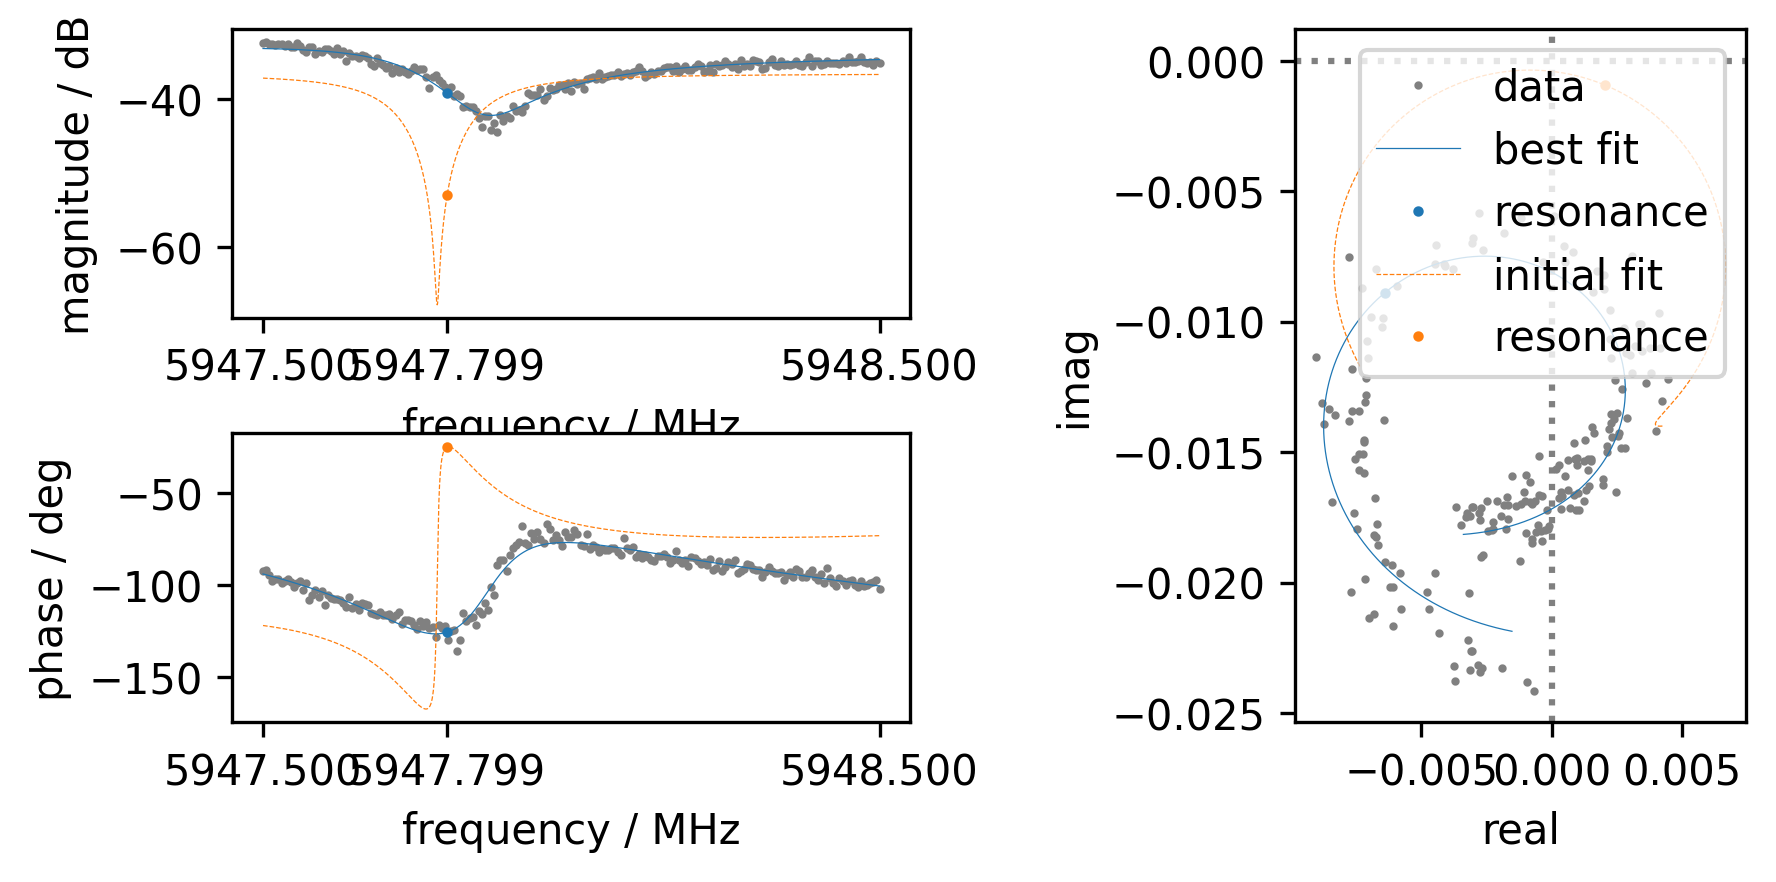

In [58]:
fig, (ax_magnitude, ax_phase, ax_complex) = see.triptych(resonator=lsf, plot_initial=True, frequency_scale=1e-6, normalize=False, figure_settings={'figsize': (7, 3), 'dpi': 300})
ax_complex.legend()
fig.savefig("example_raw.png")

In [59]:
print(lsf.result.fit_report())

[[Model]]
    (Model(magnitude_phase_delay) * Model(linear_shunt))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 89
    # data points      = 402
    # variables        = 7
    chi-square         = 3.1511e-04
    reduced chi-square = 7.9776e-07
    Akaike info crit   = -5637.72990
    Bayesian info crit = -5609.75474
    R-squared          = -3.1511e+11
[[Variables]]
    frequency_reference:  5.948e+09 (fixed)
    magnitude:            0.02072360 +/- 1.6051e-04 (0.77%) (init = 0.01479351)
    phase:               -1.59635454 +/- 0.00592276 (0.37%) (init = -1.599042)
    delay:               -9.3932e-08 +/- 3.3977e-09 (3.62%) (init = 5.682544e-08)
    resonance_frequency:  5.9478e+09 +/- 3596.99988 (0.00%) (init = 5.947782e+09)
    coupling_loss:        3.5490e-05 +/- 1.0603e-06 (2.99%) (init = 3.515591e-05)
    internal_loss:        2.3530e-05 +/- 7.8292e-07 (3.33%) (init = 9.920125e-07)
    asymmetry:            0.57759616 +/- 0.02189600 (3.79%) (init = 0

In [60]:
print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))
print("The coupling quality factor is Q_c = {:.0f}".format(lsf.Q_c))
print("The total quality factor is Q_t = {:.0f}".format(lsf.Q_t))
print("The standard error of the resonance frequency is: {:.0f} Hz".format(lsf.f_r_error))
print("The total energy decay rate is 2 pi f_r / Q_t = {:.0f} s^-1".format(lsf.total_energy_decay_rate))
#print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))


The internal quality factor is Q_i = 42499
The coupling quality factor is Q_c = 28177
The total quality factor is Q_t = 16944
The standard error of the resonance frequency is: 3597 Hz
The total energy decay rate is 2 pi f_r / Q_t = 2205627 s^-1


In [61]:
lsf.resonance_frequency/1e9

5.947798794358646

### Q4

In [62]:
sub_folder = r'\xld_sample_data\ES-004-D\Q4\2025-11-10 STS_Power'

In [63]:
pth = root_folder + sub_folder

directory = os.fsencode(pth)

file_list = []
file_name_list = []
for file in os.listdir(directory):
     filename = os.fsdecode(file)
     if filename.endswith(".mat"): #Check how your files are named
            file_name_list.append(filename)
            continue
     else:
         continue

file_list = [os.path.join(pth,file).replace(os.sep, '/') for file in file_name_list]
print(np.size(file_list))

results_folder = r'\Results'
results_pth = pth+results_folder
Path(results_pth).mkdir(parents=True, exist_ok=True)
print(results_pth)

1
C:\Users\shvetso1\OneDrive - Aalto University\Documents\xld_sample_data\ES-004-D\Q4\2025-11-10 STS_Power\Results


In [64]:
print(file_list[0])

C:/Users/shvetso1/OneDrive - Aalto University/Documents/xld_sample_data/ES-004-D/Q4/2025-11-10 STS_Power/S12(f=6.17to6.18GHz)(P=10to-45dBm)_flux=0mA-20251110T112004.mat


In [65]:
mat = scipy.io.loadmat(file_list[0])

In [66]:
mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Nov 10 11:23:12 2025',
 '__version__': '1.0',
 '__globals__': [],
 'Att_input': array([[62]], dtype=uint8),
 'Att_probe': array([[13]], dtype=uint8),
 'Conf': array([[(array(['STS_OUT_1p2_IN_1p11_'], dtype='<U20'), array([[75]], dtype=uint8))]],
       dtype=[('setup', 'O'), ('IFbw', 'O')]),
 'flux': array([[0]], dtype=uint8),
 'freq_scan': array([[6.16900e+09, 6.16901e+09, 6.16902e+09, ..., 6.17898e+09,
         6.17899e+09, 6.17900e+09]]),
 'mag_2darray': array([[-33.93314914, -33.93442517, -33.92873885, ..., -34.18524354,
         -34.19259786, -34.19329153],
        [-33.97040235, -33.97155291, -33.96680402, ..., -34.23326712,
         -34.22616878, -34.23003049],
        [-34.01300817, -34.00934329, -34.01997821, ..., -34.27752033,
         -34.28366311, -34.28368468],
        ...,
        [-34.42958041, -34.37960488, -34.36596989, ..., -34.96805138,
         -34.62211617, -34.5991111 ],
        [-34.30503224

In [67]:
mat['power'][0][10]

-40

In [68]:
np.size(mat['pha_2darray'][10])

1001

In [69]:
plt.close('all')
freq = (mat['freq_scan'][0])
x = pow(10, (mat['mag_2darray'][10])/20)
phase = np.unwrap(mat['pha_2darray'][10])
#phase = np.unwrap(mat1['pha_2darray'][2])
S21_vect = remove_cable_delay(freq, np.vectorize(complex)(x*np.cos(phase),(x*np.sin(phase))), delay = 0)
#data=np.vectorize(complex)(mat1['mag_2darray'][2]*np.cos(phase),(mat1['mag_2darray'][2]*np.sin(phase)))
data = S21_vect

In [70]:
# Background model and parameters
background_model = background.MagnitudePhaseDelay()
magnitude = 0.01
phase = 0
delay = 300e-9  # This corresponds to a long microwave cable
lsf = shunt.LinearShuntFitter(frequency=freq, data=data, background_model=background.MagnitudePhaseDelay())

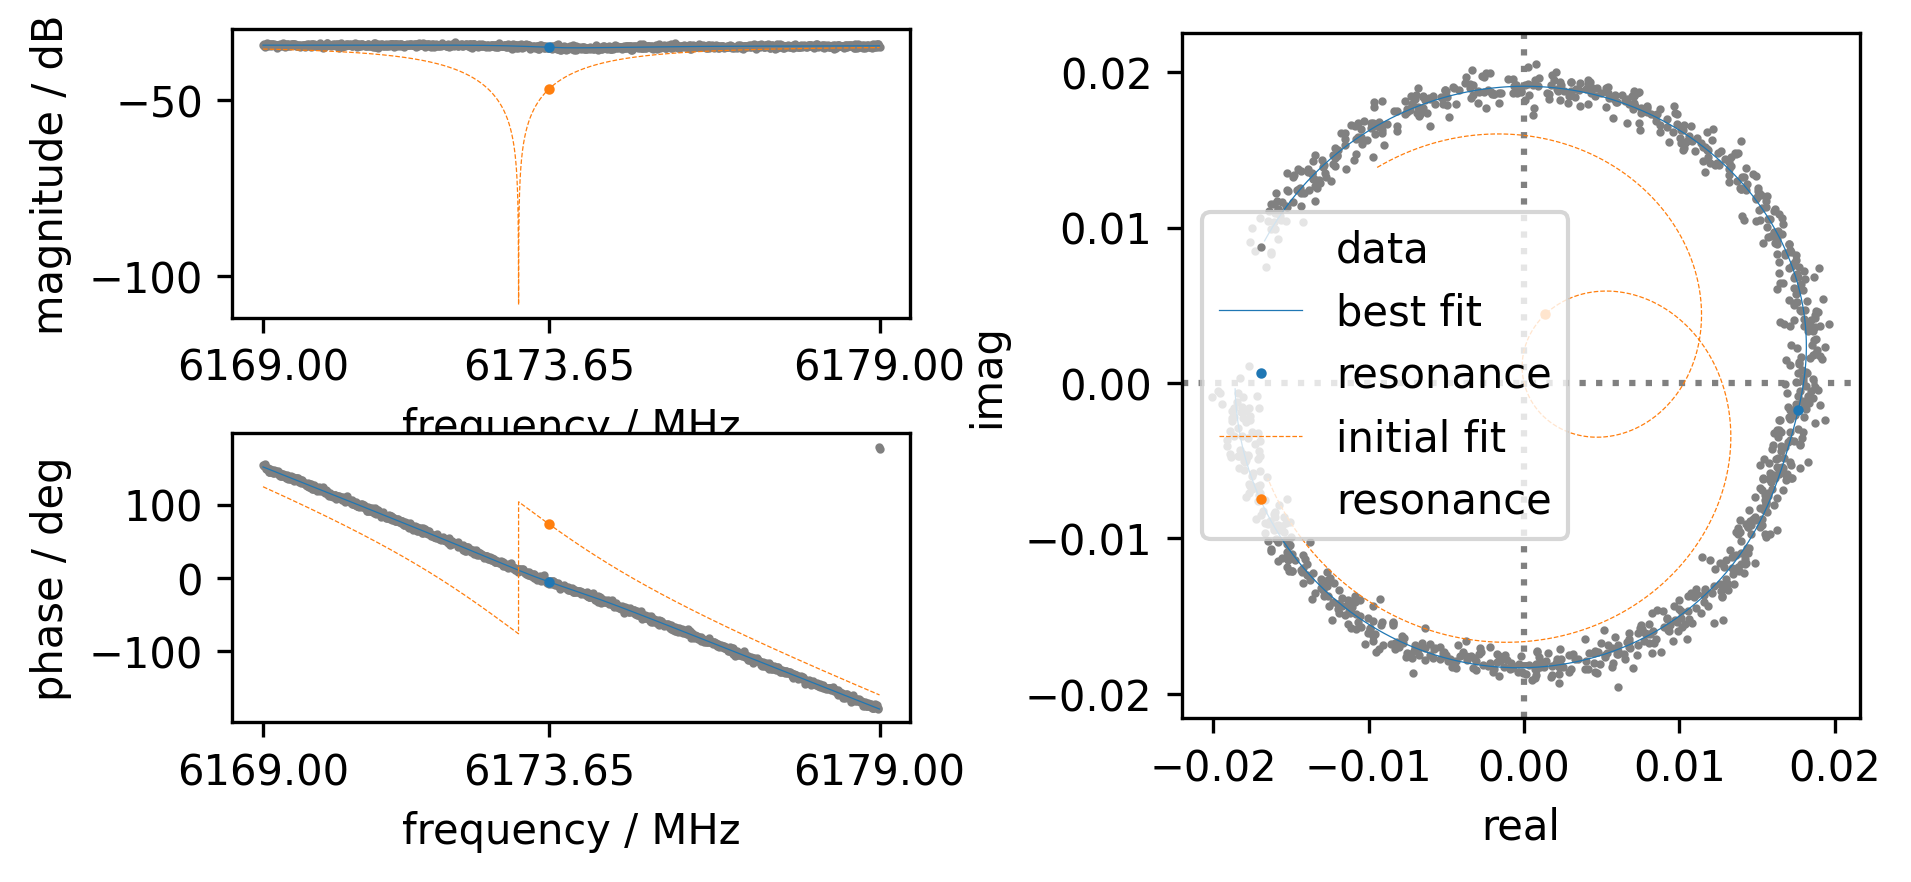

In [71]:
fig, (ax_magnitude, ax_phase, ax_complex) = see.triptych(resonator=lsf, plot_initial=True, frequency_scale=1e-6, normalize=False, figure_settings={'figsize': (7, 3), 'dpi': 300})
ax_complex.legend()
fig.savefig("example_raw.png")

In [72]:
print(lsf.result.fit_report())

[[Model]]
    (Model(magnitude_phase_delay) * Model(linear_shunt))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 243
    # data points      = 2002
    # variables        = 7
    chi-square         = 8.1291e-04
    reduced chi-square = 4.0748e-07
    Akaike info crit   = -29449.0110
    Bayesian info crit = -29409.7977
    R-squared          = -8.1291e+11
[[Variables]]
    frequency_reference:  6.174e+09 (fixed)
    magnitude:            0.01885281 +/- 3.4202e-05 (0.18%) (init = 0.0185546)
    phase:               -0.23703866 +/- 0.00148545 (0.63%) (init = -0.2489133)
    delay:               -9.2096e-08 +/- 8.6201e-11 (0.09%) (init = -9.097059e-08)
    resonance_frequency:  6.1736e+09 +/- 61318.0224 (0.00%) (init = 6.173145e+09)
    coupling_loss:        2.0017e-05 +/- 1.9458e-06 (9.72%) (init = 0.0006319312)
    internal_loss:        3.0654e-04 +/- 1.8362e-05 (5.99%) (init = 1e-12)
    asymmetry:            1.00553893 +/- 0.11723925 (11.66%) (init = 0)
[

In [73]:
print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))
print("The coupling quality factor is Q_c = {:.0f}".format(lsf.Q_c))
print("The total quality factor is Q_t = {:.0f}".format(lsf.Q_t))
print("The standard error of the resonance frequency is: {:.0f} Hz".format(lsf.f_r_error))
print("The total energy decay rate is 2 pi f_r / Q_t = {:.0f} s^-1".format(lsf.total_energy_decay_rate))
#print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))


The internal quality factor is Q_i = 3262
The coupling quality factor is Q_c = 49957
The total quality factor is Q_t = 3062
The standard error of the resonance frequency is: 61318 Hz
The total energy decay rate is 2 pi f_r / Q_t = 12667342 s^-1


In [74]:
lsf.resonance_frequency/1e9

6.173645221436876

### Q6

In [93]:
sub_folder = r'\xld_sample_data\ES-004-D\Q6\2025-11-10 STS_Power'

In [94]:
pth = root_folder + sub_folder

directory = os.fsencode(pth)

file_list = []
file_name_list = []
for file in os.listdir(directory):
     filename = os.fsdecode(file)
     if filename.endswith(".mat"): #Check how your files are named
            file_name_list.append(filename)
            continue
     else:
         continue

file_list = [os.path.join(pth,file).replace(os.sep, '/') for file in file_name_list]
print(np.size(file_list))

results_folder = r'\Results'
results_pth = pth+results_folder
Path(results_pth).mkdir(parents=True, exist_ok=True)
print(results_pth)

1
C:\Users\shvetso1\OneDrive - Aalto University\Documents\xld_sample_data\ES-004-D\Q6\2025-11-10 STS_Power\Results


In [95]:
print(file_list[0])

C:/Users/shvetso1/OneDrive - Aalto University/Documents/xld_sample_data/ES-004-D/Q6/2025-11-10 STS_Power/S12(f=6.86to6.86GHz)(P=10to-45dBm)_flux=0mA-20251110T113037.mat


In [96]:
mat = scipy.io.loadmat(file_list[0])

In [97]:
mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Nov 10 11:32:06 2025',
 '__version__': '1.0',
 '__globals__': [],
 'Att_input': array([[62]], dtype=uint8),
 'Att_probe': array([[13]], dtype=uint8),
 'Conf': array([[(array(['STS_OUT_1p2_IN_1p11_'], dtype='<U20'), array([[75]], dtype=uint8))]],
       dtype=[('setup', 'O'), ('IFbw', 'O')]),
 'flux': array([[0]], dtype=uint8),
 'freq_scan': array([[6.855000e+09, 6.855005e+09, 6.855010e+09, 6.855015e+09,
         6.855020e+09, 6.855025e+09, 6.855030e+09, 6.855035e+09,
         6.855040e+09, 6.855045e+09, 6.855050e+09, 6.855055e+09,
         6.855060e+09, 6.855065e+09, 6.855070e+09, 6.855075e+09,
         6.855080e+09, 6.855085e+09, 6.855090e+09, 6.855095e+09,
         6.855100e+09, 6.855105e+09, 6.855110e+09, 6.855115e+09,
         6.855120e+09, 6.855125e+09, 6.855130e+09, 6.855135e+09,
         6.855140e+09, 6.855145e+09, 6.855150e+09, 6.855155e+09,
         6.855160e+09, 6.855165e+09, 6.855170e+09, 6.855175e+09,


In [98]:
mat['power'][0][10]

-40

In [99]:
np.size(mat['pha_2darray'][10])

401

In [100]:
plt.close('all')
freq = (mat['freq_scan'][0])
x = pow(10, (mat['mag_2darray'][10])/20)
phase = np.unwrap(mat['pha_2darray'][10])
#phase = np.unwrap(mat1['pha_2darray'][2])
S21_vect = remove_cable_delay(freq, np.vectorize(complex)(x*np.cos(phase),(x*np.sin(phase))), delay = 0)
#data=np.vectorize(complex)(mat1['mag_2darray'][2]*np.cos(phase),(mat1['mag_2darray'][2]*np.sin(phase)))
data = S21_vect

In [101]:
# Background model and parameters
background_model = background.MagnitudePhaseDelay()
magnitude = 0.01
phase = 0
delay = 300e-9  # This corresponds to a long microwave cable
lsf = shunt.LinearShuntFitter(frequency=freq, data=data, background_model=background.MagnitudePhaseDelay())

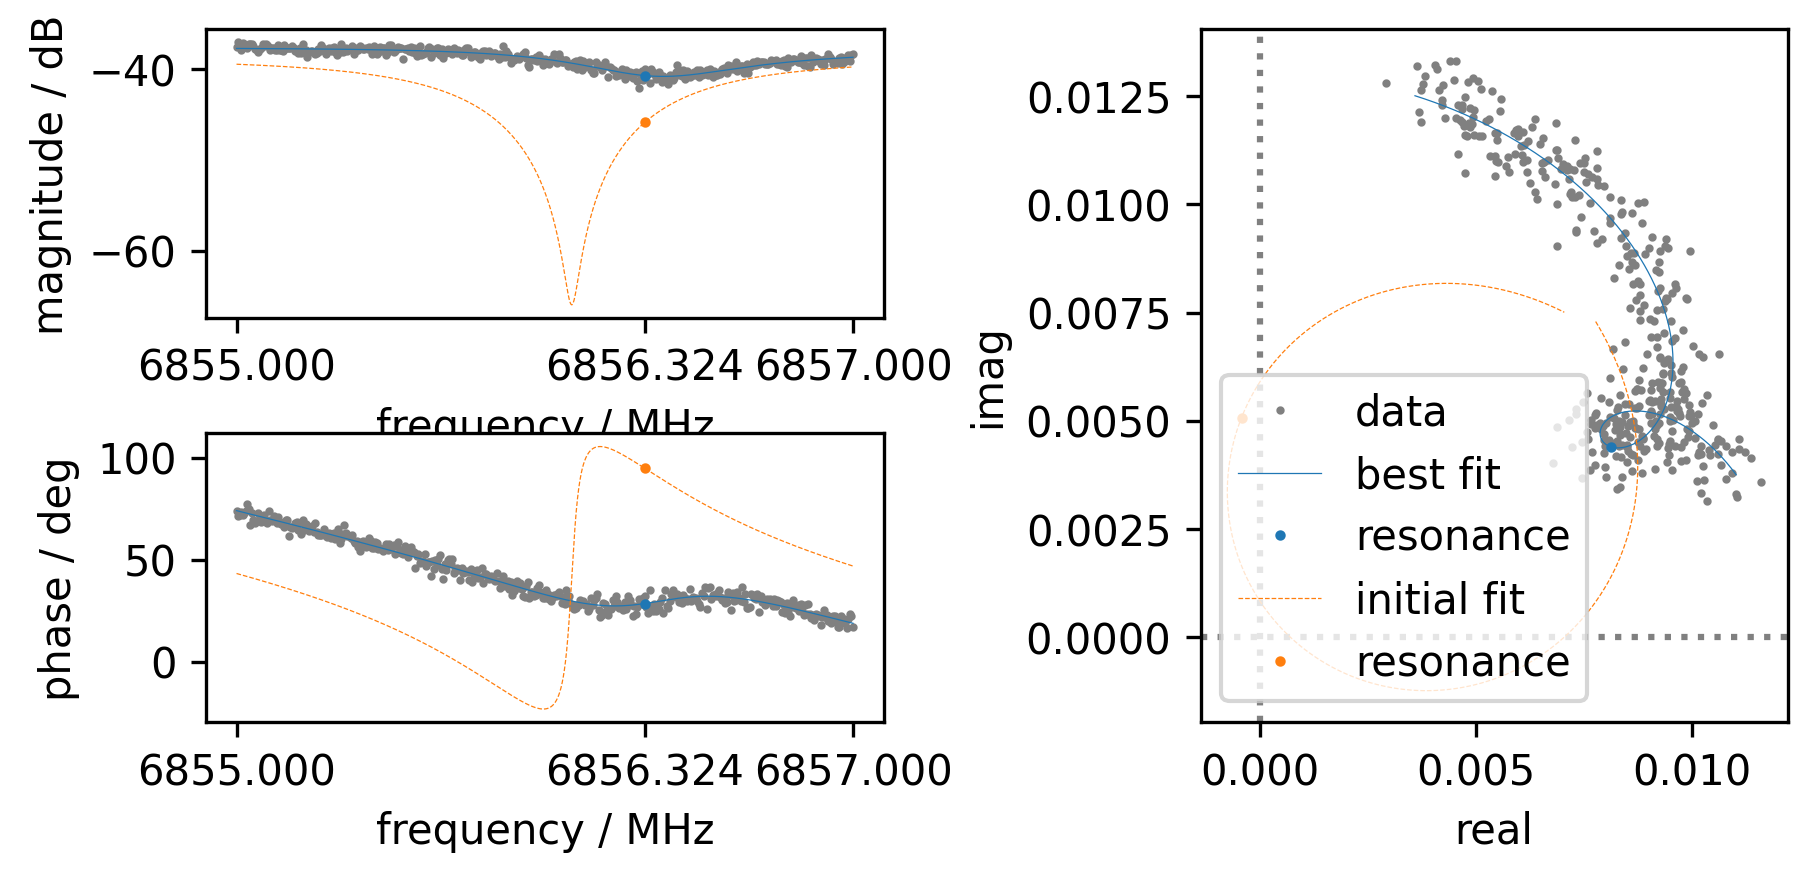

In [102]:
fig, (ax_magnitude, ax_phase, ax_complex) = see.triptych(resonator=lsf, plot_initial=True, frequency_scale=1e-6, normalize=False, figure_settings={'figsize': (7, 3), 'dpi': 300})
ax_complex.legend()
fig.savefig("example_raw.png")

In [103]:
print(lsf.result.fit_report())

[[Model]]
    (Model(magnitude_phase_delay) * Model(linear_shunt))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 75
    # data points      = 802
    # variables        = 7
    chi-square         = 1.8531e-04
    reduced chi-square = 2.3310e-07
    Akaike info crit   = -12241.0290
    Bayesian info crit = -12208.2192
    R-squared          = -1.8531e+11
[[Variables]]
    frequency_reference:  6.856e+09 (fixed)
    magnitude:            0.01303587 +/- 8.3394e-05 (0.64%) (init = 0.01169291)
    phase:                0.79259003 +/- 0.00433477 (0.55%) (init = 0.7526122)
    delay:               -9.3973e-08 +/- 1.1508e-09 (1.22%) (init = -6.477804e-08)
    resonance_frequency:  6.8563e+09 +/- 15048.2393 (0.00%) (init = 6.856088e+09)
    coupling_loss:        3.5930e-05 +/- 1.6505e-06 (4.59%) (init = 0.0001374979)
    internal_loss:        8.5404e-05 +/- 2.6643e-06 (3.12%) (init = 6.170085e-06)
    asymmetry:            0.24883296 +/- 0.04527098 (18.19%) (init =

In [104]:
print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))
print("The coupling quality factor is Q_c = {:.0f}".format(lsf.Q_c))
print("The total quality factor is Q_t = {:.0f}".format(lsf.Q_t))
print("The standard error of the resonance frequency is: {:.0f} Hz".format(lsf.f_r_error))
print("The total energy decay rate is 2 pi f_r / Q_t = {:.0f} s^-1".format(lsf.total_energy_decay_rate))
#print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))


The internal quality factor is Q_i = 11709
The coupling quality factor is Q_c = 27832
The total quality factor is Q_t = 8242
The standard error of the resonance frequency is: 15048 Hz
The total energy decay rate is 2 pi f_r / Q_t = 5227011 s^-1


In [105]:
lsf.resonance_frequency/1e9

6.856324294215008

### Q5

In [106]:
sub_folder = r'\xld_sample_data\ES-004-D\Q5\2025-11-10 STS_Power'

In [107]:
pth = root_folder + sub_folder

directory = os.fsencode(pth)

file_list = []
file_name_list = []
for file in os.listdir(directory):
     filename = os.fsdecode(file)
     if filename.endswith(".mat"): #Check how your files are named
            file_name_list.append(filename)
            continue
     else:
         continue

file_list = [os.path.join(pth,file).replace(os.sep, '/') for file in file_name_list]
print(np.size(file_list))

results_folder = r'\Results'
results_pth = pth+results_folder
Path(results_pth).mkdir(parents=True, exist_ok=True)
print(results_pth)

1
C:\Users\shvetso1\OneDrive - Aalto University\Documents\xld_sample_data\ES-004-D\Q5\2025-11-10 STS_Power\Results


In [108]:
print(file_list[0])

C:/Users/shvetso1/OneDrive - Aalto University/Documents/xld_sample_data/ES-004-D/Q5/2025-11-10 STS_Power/S12(f=6.41to6.42GHz)(P=10to-45dBm)_flux=0mA-20251110T112731.mat


In [109]:
mat = scipy.io.loadmat(file_list[0])

In [110]:
mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Nov 10 11:29:16 2025',
 '__version__': '1.0',
 '__globals__': [],
 'Att_input': array([[62]], dtype=uint8),
 'Att_probe': array([[13]], dtype=uint8),
 'Conf': array([[(array(['STS_OUT_1p2_IN_1p11_'], dtype='<U20'), array([[75]], dtype=uint8))]],
       dtype=[('setup', 'O'), ('IFbw', 'O')]),
 'flux': array([[0]], dtype=uint8),
 'freq_scan': array([[6.41000e+09, 6.41002e+09, 6.41004e+09, 6.41006e+09, 6.41008e+09,
         6.41010e+09, 6.41012e+09, 6.41014e+09, 6.41016e+09, 6.41018e+09,
         6.41020e+09, 6.41022e+09, 6.41024e+09, 6.41026e+09, 6.41028e+09,
         6.41030e+09, 6.41032e+09, 6.41034e+09, 6.41036e+09, 6.41038e+09,
         6.41040e+09, 6.41042e+09, 6.41044e+09, 6.41046e+09, 6.41048e+09,
         6.41050e+09, 6.41052e+09, 6.41054e+09, 6.41056e+09, 6.41058e+09,
         6.41060e+09, 6.41062e+09, 6.41064e+09, 6.41066e+09, 6.41068e+09,
         6.41070e+09, 6.41072e+09, 6.41074e+09, 6.41076e+09, 6.4107

In [112]:
mat['power'][0][6]

-20

In [42]:
np.size(mat['pha_2darray'][6])

201

In [113]:
plt.close('all')
freq = (mat['freq_scan'][0])
x = pow(10, (mat['mag_2darray'][6])/20)
phase = np.unwrap(mat['pha_2darray'][6])
#phase = np.unwrap(mat1['pha_2darray'][2])
S21_vect = remove_cable_delay(freq, np.vectorize(complex)(x*np.cos(phase),(x*np.sin(phase))), delay = 0)
#data=np.vectorize(complex)(mat1['mag_2darray'][2]*np.cos(phase),(mat1['mag_2darray'][2]*np.sin(phase)))
data = S21_vect

In [114]:
# Background model and parameters
background_model = background.MagnitudePhaseDelay()
magnitude = 0.01
phase = 0
delay = 300e-9  # This corresponds to a long microwave cable
lsf = shunt.LinearShuntFitter(frequency=freq, data=data, background_model=background.MagnitudePhaseDelay())

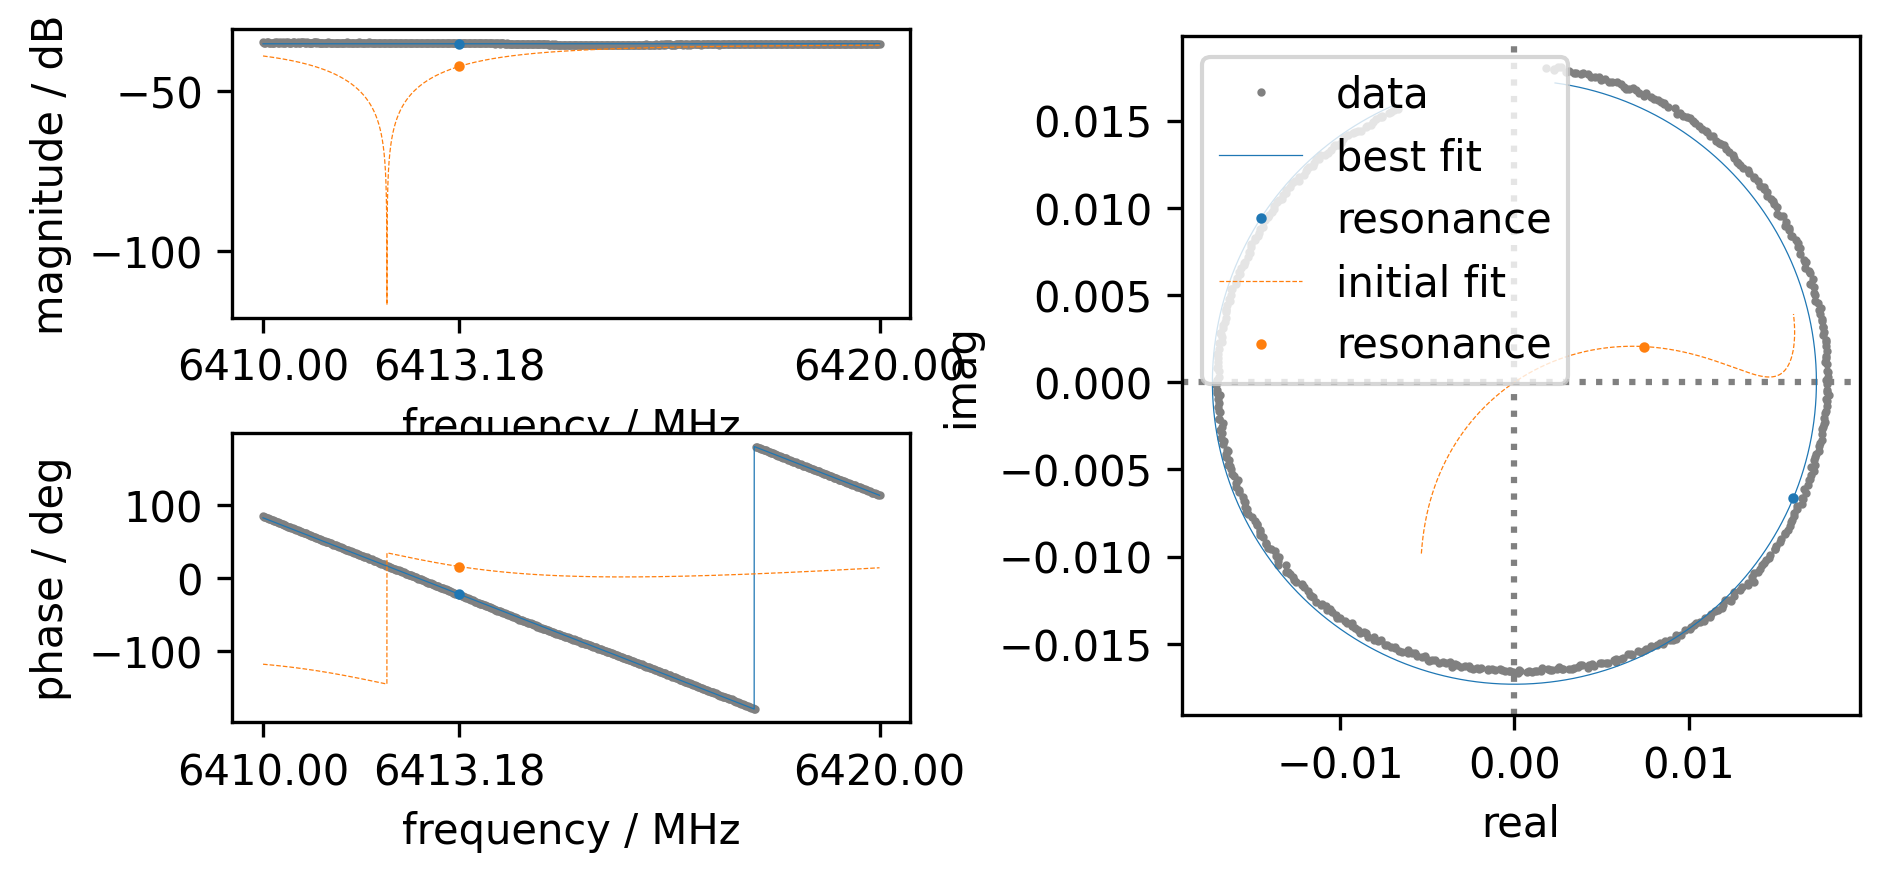

In [115]:
fig, (ax_magnitude, ax_phase, ax_complex) = see.triptych(resonator=lsf, plot_initial=True, frequency_scale=1e-6, normalize=False, figure_settings={'figsize': (7, 3), 'dpi': 300})
ax_complex.legend()
fig.savefig("example_raw.png")

In [116]:
print(lsf.result.fit_report())

[[Model]]
    (Model(magnitude_phase_delay) * Model(linear_shunt))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 217
    # data points      = 1002
    # variables        = 7
    chi-square         = 1.9913e-04
    reduced chi-square = 2.0013e-07
    Akaike info crit   = -15448.1875
    Bayesian info crit = -15413.8192
    R-squared          = (0.9867095656962803+0.005801489180690817j)
[[Variables]]
    frequency_reference:  6.415e+09 (fixed)
    magnitude:            0.01731373 +/- 4.24805568 (24535.77%) (init = 0.01716296)
    phase:               -1.43689225 +/- 263.920181 (18367.43%) (init = -0.6260725)
    delay:               -9.1442e-08 +/- 1.0799e-10 (0.12%) (init = 1.848522e-08)
    resonance_frequency:  6.4132e+09 +/- 2.5943e+14 (4045311.67%) (init = 6.41201e+09)
    coupling_loss:        9.9053e-09 +/- 463.281966 (4677114559410.92%) (init = 0.0007305225)
    internal_loss:        0.98023369 +/- 2.4407e+10 (2489878515033.79%) (init = 1e-12)
    a

In [117]:
print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))
print("The coupling quality factor is Q_c = {:.0f}".format(lsf.Q_c))
print("The total quality factor is Q_t = {:.0f}".format(lsf.Q_t))
print("The standard error of the resonance frequency is: {:.0f} Hz".format(lsf.f_r_error))
print("The total energy decay rate is 2 pi f_r / Q_t = {:.0f} s^-1".format(lsf.total_energy_decay_rate))
#print("The internal quality factor is Q_i = {:.0f}".format(lsf.Q_i))


The internal quality factor is Q_i = 1
The coupling quality factor is Q_c = 100956111
The total quality factor is Q_t = 1
The standard error of the resonance frequency is: 259433258516906 Hz
The total energy decay rate is 2 pi f_r / Q_t = 39498732463 s^-1


In [118]:
lsf.resonance_frequency/1e9

6.413183442612504